<a href="https://colab.research.google.com/github/ddoneu/FinalProject-Employee-Attrition-Prediction/blob/main/Checkpoint%201/3916_final_project_professor_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether an employee will voluntarily leave the organization based on their demographic, compensation, and job-satisfaction characteristics?

**This is a prediction (umbrella) problem because:** We are forecasting a binary outcome (Attrition: Yes/No) from observable employee features — not estimating the causal effect of any single variable on attrition. Feature importance reflects predictive association, not causation.

**The decision this enables:** An HR director at a mid-size firm could use these predictions to identify which employee segments are at highest risk of leaving, and target retention interventions (flexible scheduling, compensation adjustments, career development) where predicted attrition risk is highest and intervention cost is lowest.

**Dataset:** IBM HR Analytics Employee Attrition & Performance
- **Source:** Kaggle (URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
- **N =** 1,470 employees
- **Features =** 35 (demographic, compensation, satisfaction, tenure)
- **Target variable =** `Attrition` (binary: Yes / No)
- **Access date:** April 19, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

!pip install -q kagglehub

import kagglehub
import pandas as pd

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
df = pd.read_csv(path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset shape: 1,470 rows × 35 columns

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


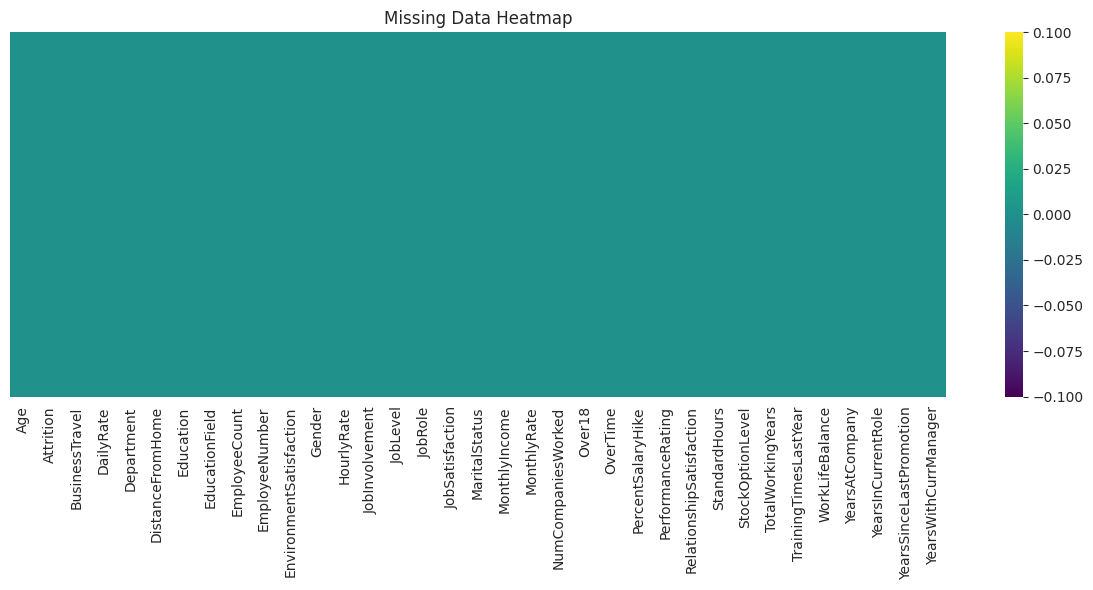

In [4]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

In [5]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})

if missing_counts.sum() == 0:
    print("Dataset completeness: 100%")
    print()
    print("-> No missing values detected.")
    print("-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.")
    print("-> No imputation strategy is needed.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

print(f"\nTotal missing values: {missing_counts.sum()}")

Dataset completeness: 100%

-> No missing values detected.
-> MCAR/MAR/MNAR classification is not applicable because there is no observed missingness.
-> No imputation strategy is needed.

Total missing values: 0


**Missing data strategy:** The dataset has zero missing values across all 1,470 observations and 35 features (100% complete). MCAR/MAR/MNAR classification is not applicable. No imputation, row deletion, or flagging is needed — the full sample is retained for modeling.

### 2.4 Distribution Plots

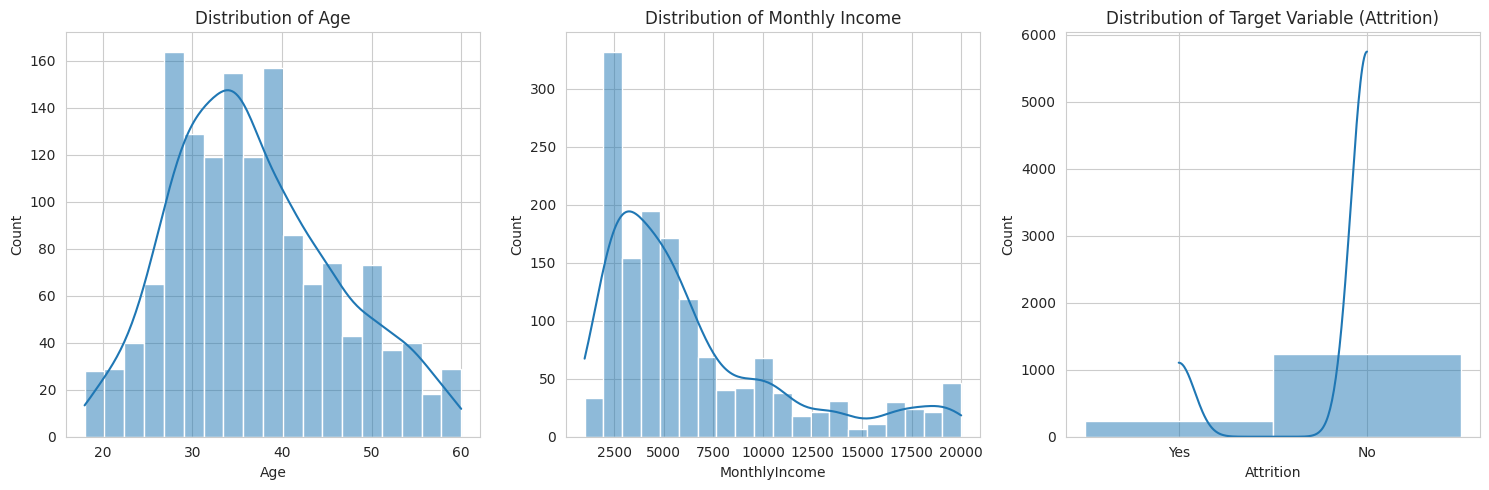

In [7]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Income')

sns.histplot(df['Attrition'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Target Variable (Attrition)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [11]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
#     """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Example: check outliers in a numeric column
col = 'MonthlyIncome'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

MonthlyIncome: 114 outliers (7.8%)


**Outlier strategy:** Keep with justification. The 114 MonthlyIncome outliers (7.8%) represent real high-earning senior employees (e.g., directors, managers at higher job levels) — they are not data errors. Removing them would bias the model by excluding a meaningful segment of the workforce. Since tree-based models (planned for the final submission) are robust to outliers, and logistic regression uses StandardScaler which reduces outlier influence, no trimming or winsorization is applied.

### 2.6 Correlations

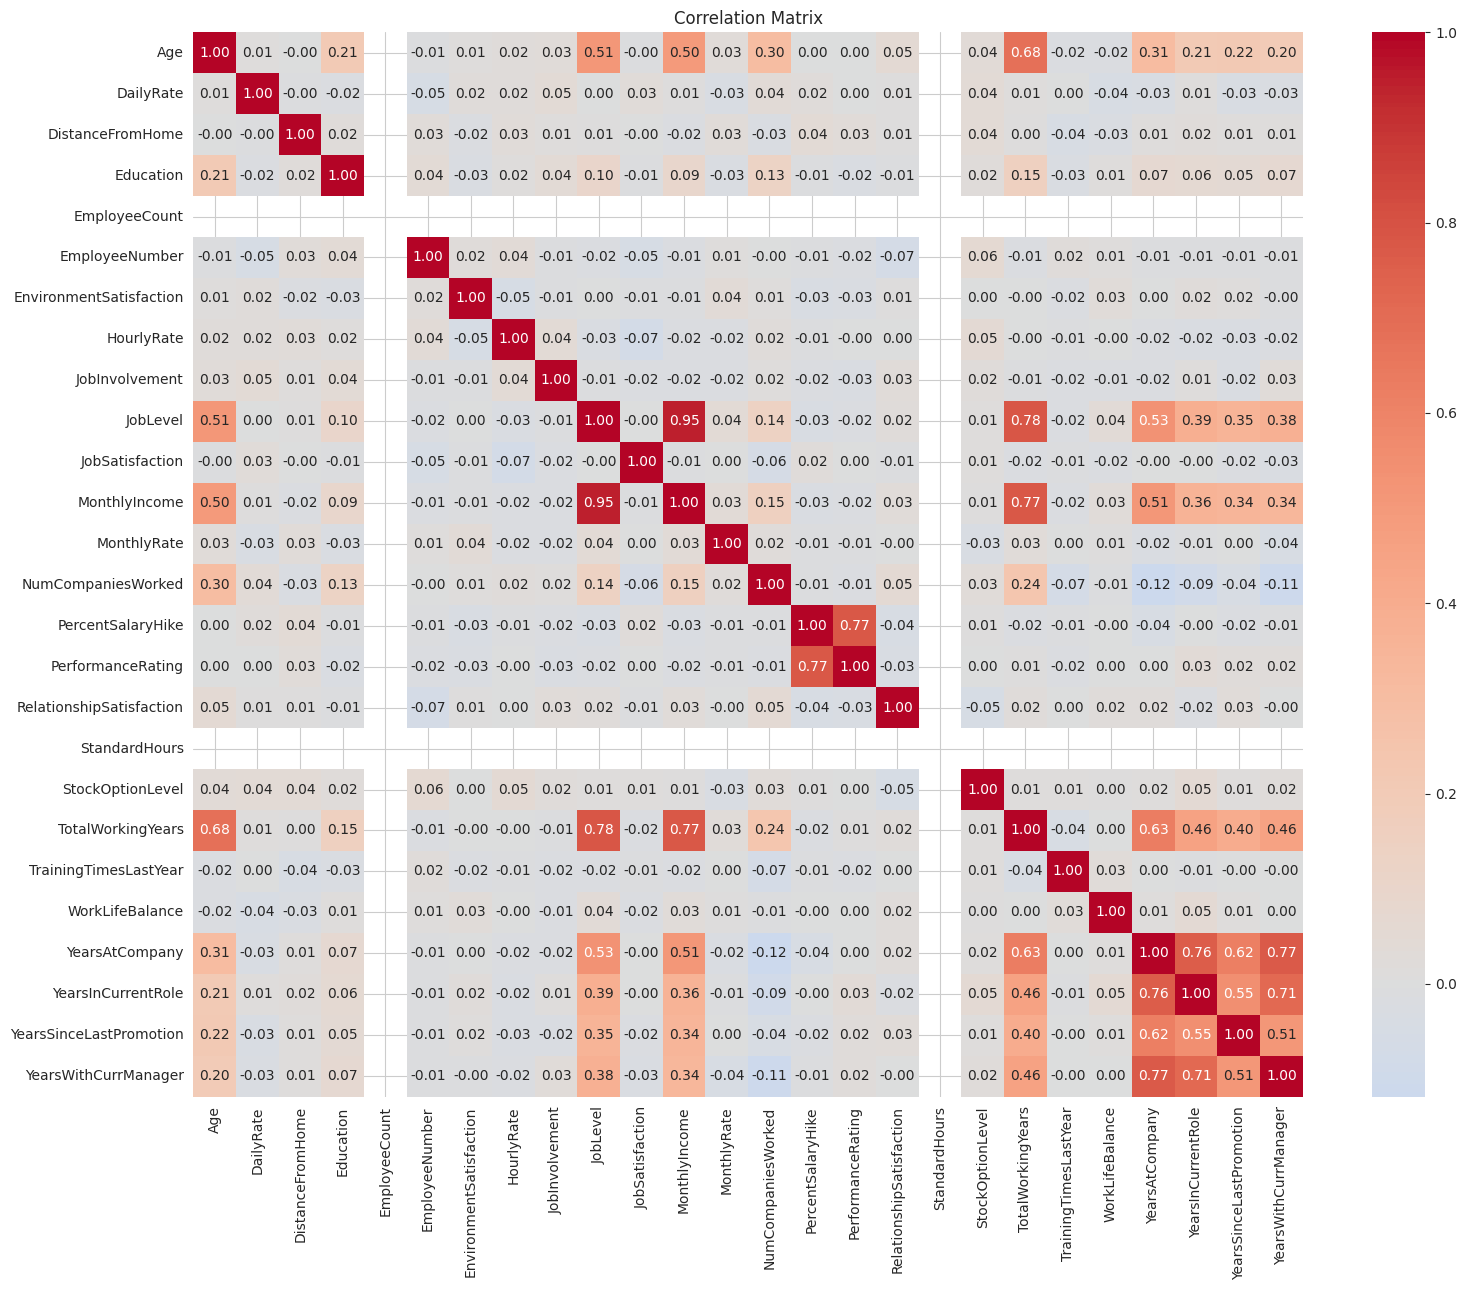

In [14]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions
1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable is `Attrition`, which is a binary classification outcome and is clearly imbalanced. About 16.1% of employees left while about 83.9% stayed, so the dataset is skewed toward the majority “Stayed” class. Because of this imbalance, I will not rely on accuracy alone and will instead focus more on recall, precision, and F1-score when evaluating models.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The numerical features with the strongest absolute correlations with attrition are `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome`, and `Age`, although all of these relationships are only moderate in size. The correlation matrix also shows notable multicollinearity among several predictors, especially `JobLevel` and `MonthlyIncome`, `TotalWorkingYears` with both `JobLevel` and `MonthlyIncome`, and the tenure-related variables `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager`. This suggests attrition is influenced by several related employee characteristics rather than one single dominant numeric factor.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue is class imbalance, not missing data, since the dataset has no observed missing values. A model could appear to perform well by mostly predicting the majority class, so I will handle this by emphasizing recall and F1-score, checking the confusion matrix carefully, and comparing models beyond simple accuracy. I will also keep an eye on multicollinearity, although it is less problematic for prediction than it would be for causal interpretation.

### 2.7 Data Quality Summary

Data Quality Summary

My dataset has N = 1,470 observations and M = 35 columns in total.

Missing data: 0% of cells are missing. The missingness pattern appears to be not applicable because there is no observed missingness in the dataset. I will handle missing data by using the full sample with no imputation.

Outliers: I identified no formal outlier count at this checkpoint using visual inspection. I will handle them by retaining plausible extreme observations for now and revisiting treatment later if they materially affect model performance.

Target variable: The target variable is imbalanced, with about 16% attrition and 84% non-attrition.

Key finding from EDA: Employees who work overtime, earn less, are younger, and have lower tenure appear more likely to leave.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [ ]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# # Define features and target
# X = df[['feature_1', 'feature_2', 'feature_3']]  # Replace with your features
# y = df['target']  # Replace with your target
#
# # For classification: use stratify=y
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
# )
#
# # For regression: remove stratify
# # X_train, X_test, y_train, y_test = train_test_split(
# #     X, y, test_size=0.2, random_state=RANDOM_STATE
# # )
#
# print(f'Train: {X_train.shape[0]} samples')
# print(f'Test:  {X_test.shape[0]} samples')

### 3.2 Model 1: Baseline

In [ ]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

# from sklearn.linear_model import LogisticRegression  # or LinearRegression, Ridge
#
# model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
# model_1.fit(X_train, y_train)
#
# y_pred_1 = model_1.predict(X_test)
#
# # Classification metrics
# print('Model 1: Logistic Regression')
# print(classification_report(y_test, y_pred_1))
#
# # Regression metrics (use these instead if regression)
# # print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
# # print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
# # print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

# from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
#
# y_pred_2 = model_2.predict(X_test)
#
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___